# DLS & Resource Methods

**Navigation**: [← Previous: Game State](02_game_state.ipynb) | [Next: Modelling →](04_modelling.ipynb)

A simplified Duckworth–Lewis–Stern resource model provides an interpretable baseline.


> **Note:** ICC uses proprietary DLS tables with protected overs. This chapter implements an **educational approximation** to teach the resource logic.

In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'cricsheet_utils.py').exists():
    PROJ_DIR = Path('projects/cricket-win-probability').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from cricsheet_utils import (
    project_data_dir, load_cricsheet_json, match_metadata, balls_to_dataframe,
    build_game_states, cumulative_runs_by_innings, resource_remaining,
    dls_win_probability,
)
DATA_DIR = project_data_dir()
SAMPLE_DIR = DATA_DIR / 'sample_matches'


## Resource remaining surface

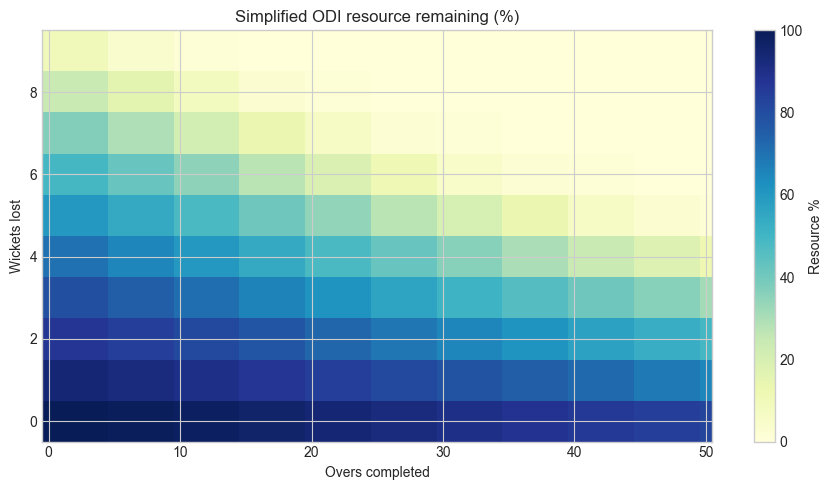

In [2]:
overs_grid = np.linspace(0, 50, 51)
wickets_grid = range(10)
surface = np.array([[resource_remaining(o, w) for o in overs_grid] for w in wickets_grid])
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(surface, aspect='auto', origin='lower', cmap='YlGnBu')
ax.set_xlabel('Overs completed')
ax.set_ylabel('Wickets lost')
ax.set_title('Simplified ODI resource remaining (%)')
plt.colorbar(im, ax=ax, label='Resource %')
plt.tight_layout()
plt.show()


## Ball-by-ball DLS probability for WC Final

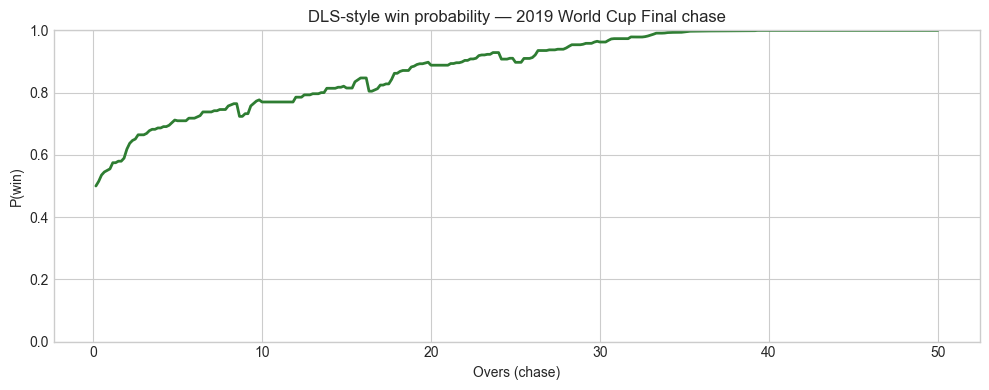

,over,runs_scored,wickets_lost,dls_prob
292,49,294,7,1.0
293,49,294,7,1.0
294,50,294,7,1.0
295,50,294,7,1.0
296,50,296,7,1.0
297,50,298,7,1.0
298,50,298,7,1.0
299,50,298,7,1.0


In [3]:
doc = load_cricsheet_json(SAMPLE_DIR / '2019_wc_final_eng_nz.json')
states = build_game_states(doc)
first_runs = int(states['target'].iloc[0] - 1)
states = states.copy()
states['dls_prob'] = dls_win_probability(states, first_runs)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(states['overs_completed'], states['dls_prob'], color='#2e7d32', linewidth=2)
ax.set_xlabel('Overs (chase)')
ax.set_ylabel('P(win)')
ax.set_ylim(0, 1)
ax.set_title('DLS-style win probability — 2019 World Cup Final chase')
plt.tight_layout()
plt.show()
states[['over', 'runs_scored', 'wickets_lost', 'dls_prob']].tail(8)


---

**Navigation**: [← Previous: Game State](02_game_state.ipynb) | [Next: Modelling →](04_modelling.ipynb)
